In [ ]:
from google.colab import files
files.upload()


Saving SIADS696-volatility-regime-modeling-main.zip to SIADS696-volatility-regime-modeling-main.zip


{'SIADS696-volatility-regime-modeling-main.zip': b'PK\x03\x04\n\x00\x00\x00\x00\x00\x16\xa7?\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00)\x00\t\x00SIADS696-volatility-regime-modeling-main/UT\x05\x00\x01\x0c\xdd~iPK\x03\x04\n\x00\x00\x00\x00\x00\x16\xa7?\\=Whw&\x00\x00\x00&\x00\x00\x002\x00\t\x00SIADS696-volatility-regime-modeling-main/README.mdUT\x05\x00\x01\x0c\xdd~i# SIADS696-volatility-regime-modeling\nPK\x03\x04\n\x00\x00\x00\x08\x00\x16\xa7?\\\xfbxE\xb9\x11\x01\x00\x00\xb2\x01\x00\x009\x00\t\x00SIADS696-volatility-regime-modeling-main/requirements.txtUT\x05\x00\x01\x0c\xdd~i-\x90Ir\xc3 \x10E\xf7\xdc\xc5]BHv\xb2\xe0,.\x84Z1e\x0c\x84!\xb6t\xfatc/[\xbc?\xe8/hZu[\xf3%\xb64i=\x81\x9c@\t\x8b\x99\xbe:\xad\xc7a<\x83\x84I\xd8\xad\x9f0\xc0 \xec\xcd\xe4\x82\xf5\x14b~\x18\xef\x0e\xccZ+\x98\x98j\xd9_\xdf\xe8\x00R\x11\xbb\xe5x`X\x9d\xad\xac\x9e\xe0"\xdc\x1a\x0c\xf3R\x8aG\xf3\xd5US\xee.\xfc\xb0\x824\xa3\x08\xed\x91\xf67,E2a5\x85q\x0eN\x88O\xc4.\xfe\xe6\xd3\x9b\xbaQ\x87\xd5\xe5\xc2\xd5g\x16

In [ ]:
!unzip SIADS696-volatility-regime-modeling-main\ \(1\).zip


unzip:  cannot find or open SIADS696-volatility-regime-modeling-main (1).zip, SIADS696-volatility-regime-modeling-main (1).zip.zip or SIADS696-volatility-regime-modeling-main (1).zip.ZIP.


In [ ]:
%cd SIADS696-volatility-regime-modeling-main


[Errno 2] No such file or directory: 'SIADS696-volatility-regime-modeling-main'
/content


In [ ]:
!ls


artifacts  README.md  requirements.txt	scripts  src


In [ ]:
!pip install -r requirements.txt


In [ ]:
%cd SIADS696-volatility-regime-modeling




[Errno 2] No such file or directory: 'SIADS696-volatility-regime-modeling'
/content/SIADS696-volatility-regime-modeling-main


In [ ]:
!ls


 artifacts	    scripts
 data		    SIADS696-volatility-regime-modeling-main
 README.md	   'SIADS696-volatility-regime-modeling-main (1).zip'
 requirements.txt   src


In [ ]:
!ls scripts


build_features.py  fetch_ohlcv.py  merge_assets_vix.py
clean_ohlcv.py	   __init__.py	   train_baseline_models.py


In [ ]:
!pip -q install -r requirements.txt


In [ ]:
!python scripts/fetch_ohlcv.py
!python scripts/clean_ohlcv.py
!python scripts/build_features.py


usage: fetch_ohlcv.py [-h] --tickers TICKERS [TICKERS ...] --start START
                      [--end END] [--interval INTERVAL] [--auto-adjust]
                      [--out-dir OUT_DIR] [--prefix PREFIX] [--out OUT]
fetch_ohlcv.py: error: the following arguments are required: --tickers, --start
usage: clean_ohlcv.py [-h] --infile INFILE --out OUT [--keep-adj-close]
clean_ohlcv.py: error: the following arguments are required: --infile, --out
usage: build_features.py [-h] --infile INFILE --out OUT [--horizon HORIZON]
                         --train-end TRAIN_END [--n-regimes N_REGIMES]
build_features.py: error: the following arguments are required: --infile, --out, --train-end


In [ ]:
!pip -q install yfinance pandas numpy scikit-learn pyarrow joblib matplotlib seaborn


In [ ]:
!python scripts/fetch_ohlcv.py \
  --tickers SPY QQQ IWM AAPL MSFT \
  --start 2015-01-01 \
  --interval 1d \
  --out artifacts/assets_raw.parquet


Saved: artifacts/assets_raw.parquet
Rows: 13,955 | Date range: 2015-01-02 → 2026-02-06 | Tickers: ['AAPL', 'IWM', 'MSFT', 'QQQ', 'SPY']


In [ ]:
!python scripts/fetch_ohlcv.py \
  --tickers ^VIX \
  --start 2015-01-01 \
  --interval 1d \
  --out artifacts/vix_raw.parquet


Saved: artifacts/vix_raw.parquet
Rows: 2,791 | Date range: 2015-01-02 → 2026-02-06 | Tickers: ['^VIX']


In [ ]:
!python scripts/clean_ohlcv.py --infile artifacts/assets_raw.parquet --out artifacts/assets_clean.parquet
!python scripts/clean_ohlcv.py --infile artifacts/vix_raw.parquet --out artifacts/vix_clean.parquet


In [ ]:
!python scripts/merge_assets_vix.py \
  --assets artifacts/assets_clean.parquet \
  --vix artifacts/vix_clean.parquet \
  --out artifacts/assets_with_vix.parquet


Saved merged dataset to: artifacts/assets_with_vix.parquet
Rows: 13955
Missing VIX rows: 0
Date range: 2015-01-02 00:00:00 → 2026-02-06 00:00:00


In [ ]:
!python scripts/build_features.py \
  --infile artifacts/assets_with_vix.parquet \
  --out artifacts/vol_features_5d.parquet \
  --horizon 5 \
  --train-end 2022-12-31 \
  --n-regimes 3


In [ ]:
!ls -lah artifacts | sed -n '1,200p'


total 3.9M
drwxr-xr-x 3 root root 4.0K Feb  7 14:54 .
drwxr-xr-x 7 root root 4.0K Feb  7 14:59 ..
-rw-r--r-- 1 root root 607K Feb  7 15:22 assets_clean.parquet
-rw-r--r-- 1 root root 607K Feb  7 15:22 assets_raw.parquet
-rw-r--r-- 1 root root 737K Feb  7 15:22 assets_with_vix.parquet
drwxr-xr-x 2 root root 4.0K Feb  6 18:57 baseline
-rw-r--r-- 1 root root  87K Feb  7 15:22 vix_clean.parquet
-rw-r--r-- 1 root root  87K Feb  7 15:22 vix_raw.parquet
-rw-r--r-- 1 root root 1.8M Feb  7 15:22 vol_features_5d.parquet


In [ ]:
import pandas as pd
df = pd.read_parquet("artifacts/vol_features_5d.parquet")
df.head(), df.shape

(        date ticker       open       high        low      close  adj_close  \
 0 2015-03-31   AAPL  31.522499  31.622499  31.090000  31.107500  27.693960   
 1 2015-04-01   AAPL  31.205000  31.280001  30.775000  31.062500  27.653902   
 2 2015-04-02   AAPL  31.257500  31.389999  31.047501  31.330000  27.892054   
 3 2015-04-06   AAPL  31.117500  31.877501  31.082500  31.837500  28.343857   
 4 2015-04-07   AAPL  31.910000  32.029999  31.495001  31.502501  28.045620   
 
       volume  vix_close  vix_volume  ...  log_return     rv_10     rv_20  \
 0  168362400      15.29           0  ...   -0.015471  0.242516  0.228820   
 1  162485600      15.11           0  ...   -0.001448  0.231187  0.228226   
 2  128880400      14.67           0  ...    0.008575  0.237041  0.223771   
 3  148776000      14.74           0  ...    0.016069  0.243759  0.231289   
 4  140049200      14.78           0  ...   -0.010578  0.244268  0.233899   
 
       rv_60  vol_mean_10    vol_std_10  vol_mean_20    vol_

In [ ]:
!mkdir -p figures

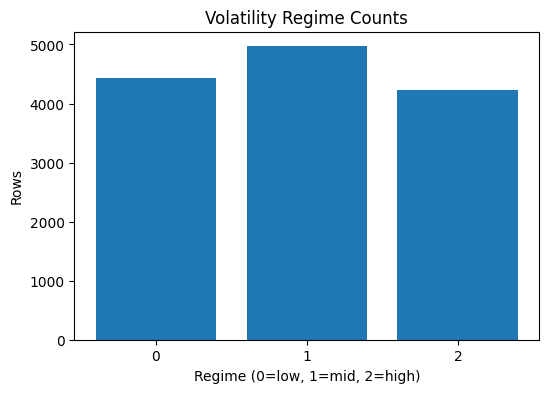

regime
0    4429
1    4968
2    4233
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import os
os.makedirs("figures", exist_ok=True)


counts = df["regime"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Volatility Regime Counts")
plt.xlabel("Regime (0=low, 1=mid, 2=high)")
plt.ylabel("Rows")

# Create the 'figures' directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/regime_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


counts

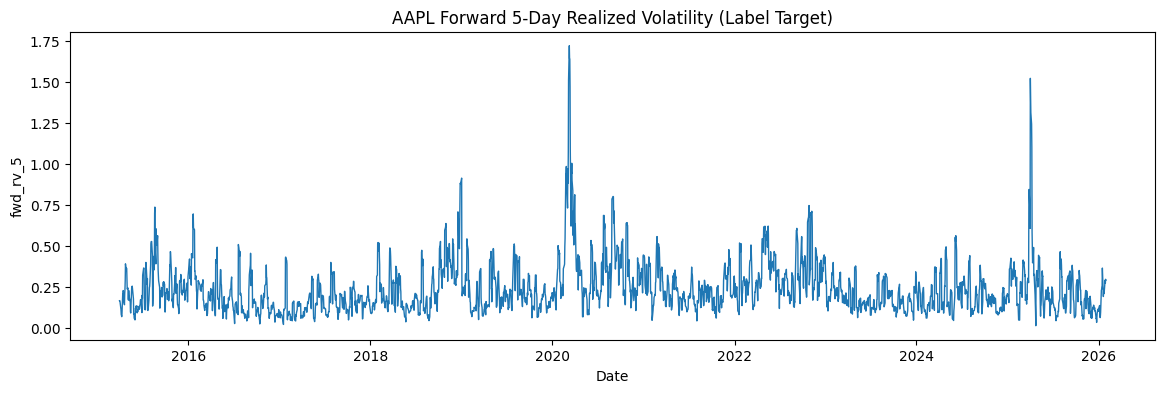

In [ ]:
g = df[df["ticker"]=="AAPL"].sort_values("date")

plt.figure(figsize=(14,4))
plt.plot(g["date"], g["fwd_rv_5"], linewidth=1)
plt.title("AAPL Forward 5-Day Realized Volatility (Label Target)")
plt.xlabel("Date")
plt.ylabel("fwd_rv_5")
plt.savefig("figures/volatility_over_time_aapl.png", dpi=150, bbox_inches="tight")
plt.show()


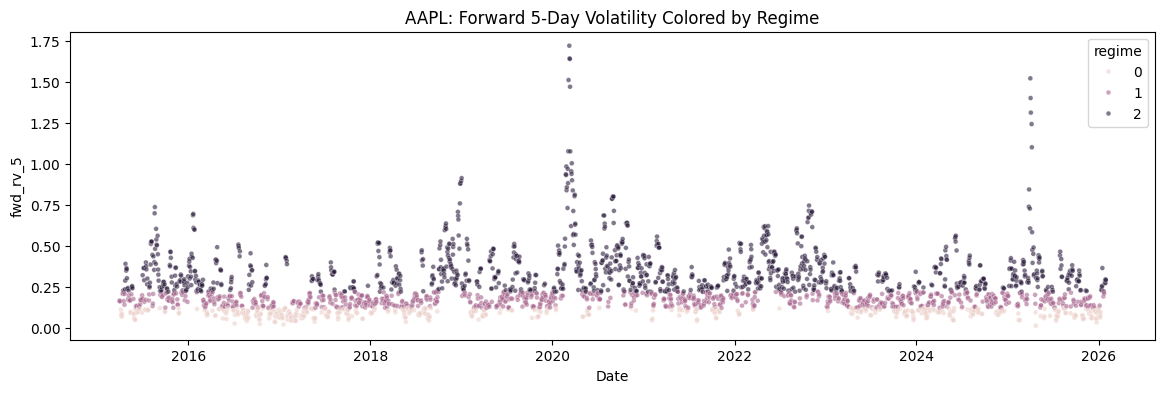

In [ ]:
import seaborn as sns

plt.figure(figsize=(14,4))
sns.scatterplot(data=g, x="date", y="fwd_rv_5", hue="regime", s=12, alpha=0.6)
plt.title("AAPL: Forward 5-Day Volatility Colored by Regime")
plt.xlabel("Date")
plt.ylabel("fwd_rv_5")
plt.savefig("figures/regime_colored_volatility.png", dpi=150, bbox_inches="tight")
plt.show()


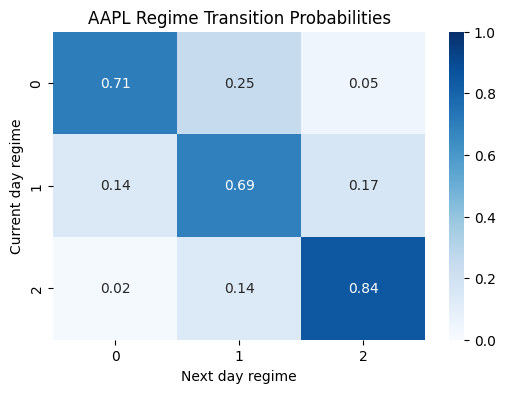

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def transition_matrix(regimes: pd.Series, n_states: int = 3):
    r = regimes.dropna().astype(int).values
    if len(r) < 2:
        return np.full((n_states, n_states), np.nan)
    mat = np.zeros((n_states, n_states), dtype=float)
    for a, b in zip(r[:-1], r[1:]):
        mat[a, b] += 1
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        mat = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)
    return mat

ticker = "AAPL"
g = df[df["ticker"] == ticker].sort_values("date")

tm = transition_matrix(g["regime"], n_states=3)

plt.figure(figsize=(6,4))
sns.heatmap(tm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title(f"{ticker} Regime Transition Probabilities")
plt.xlabel("Next day regime")
plt.ylabel("Current day regime")
plt.savefig("figures/regime_transition_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



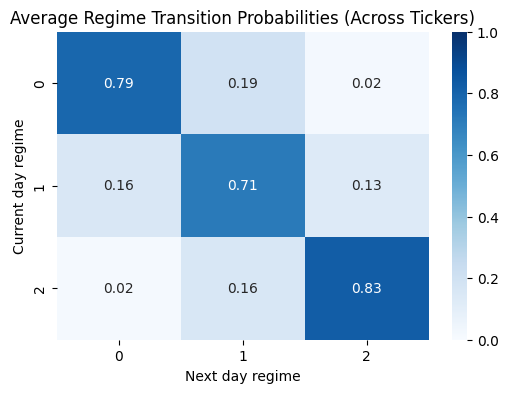

In [ ]:
mats = []
for t, g in df.sort_values(["ticker","date"]).groupby("ticker"):
    mats.append(transition_matrix(g["regime"], n_states=3))

avg_tm = np.nanmean(np.stack(mats), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(avg_tm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Average Regime Transition Probabilities (Across Tickers)")
plt.xlabel("Next day regime")
plt.ylabel("Current day regime")
plt.savefig("figures/regime_transition_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



In [ ]:
import joblib

rf = joblib.load("artifacts/baseline/rf.joblib")
rf


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       n_jobs=-1, random_state=42)

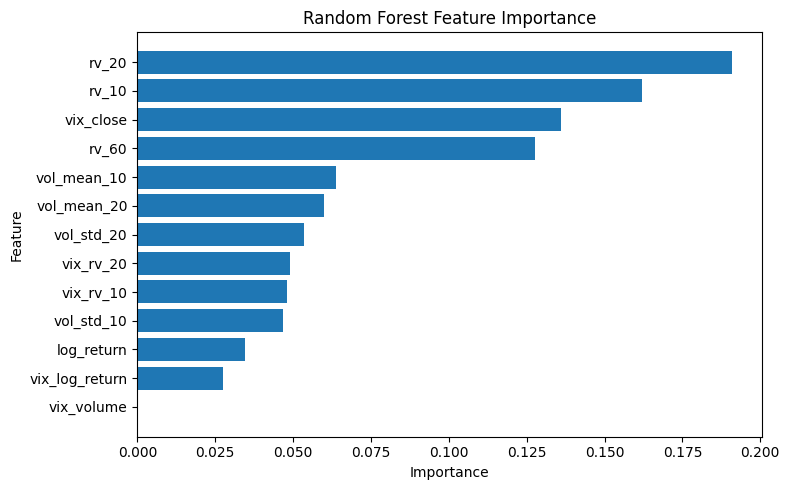

rv_20             0.190975
rv_10             0.161904
vix_close         0.136063
rv_60             0.127807
vol_mean_10       0.063906
vol_mean_20       0.059924
vol_std_20        0.053404
vix_rv_20         0.048988
vix_rv_10         0.048192
vol_std_10        0.046684
log_return        0.034520
vix_log_return    0.027631
vix_volume        0.000000
dtype: float64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_cols = list(rf.feature_names_in_)
importances = pd.Series(rf.feature_importances_, index=feat_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


importances


In [ ]:
!zip -r figures.zip figures
from google.colab import files
files.download("figures.zip")


  adding: figures/ (stored 0%)
  adding: figures/regime_transition_heatmap.png (deflated 10%)
  adding: figures/volatility_over_time_aapl.png (deflated 5%)
  adding: figures/rf_feature_importance.png (deflated 21%)
  adding: figures/regime_colored_volatility.png (deflated 3%)
  adding: figures/regime_distribution.png (deflated 22%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls


artifacts  figures  figures.zip  README.md  requirements.txt  scripts  src


In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# ---- adjust if needed ----
metrics_path = Path("/content/metrics.json")

# ---- load metrics ----
with open(metrics_path, "r") as f:
    data = json.load(f)

models = data["models"]

metric_keys = [
    ("accuracy", "Accuracy"),
    ("f1_macro", "F1 (Macro)"),
    ("roc_auc", "ROC AUC (OvR)"),
]

model_order = list(models.keys())
bar_width = 0.35
x = range(len(metric_keys))

plt.figure()

for i, model_name in enumerate(model_order):
    m = models[model_name]
    values = []

    for key, _ in metric_keys:
        if key == "accuracy":
            values.append(m["classification_report"]["accuracy"])
        else:
            values.append(m[key])

    offsets = [xi + (i - 0.5) * bar_width for xi in x]
    plt.bar(offsets, values, width=bar_width, label=model_name)

plt.ylim(0, 1)
plt.xticks(range(len(metric_keys)), [label for _, label in metric_keys])
plt.ylabel("Score")
plt.title("Baseline Model Performance")
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/metrics.json'